# Asset Pricing & Risk Group Project: Portfolio Optimization with Dow Jones 30 Stocks
#### Group 2 : Iker Caballero, Anushka Dhar, Rohan Dinesh, Dylan Ottey
---------------------

### Package Initialization

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
from utils.visualization import portfolio_sampler, mv_plot, DataAnalysisPlots
from utils.helpers import ptf_results_print, ann_rets, cov_mat
from utils.optimisers import markowitz_tangency_ptf, resampling_optimiser
from utils.types import plot_ptf
from utils.enums import FreqPrices

### Specify Parameters

In [3]:
RANDOM_SEED = 123
OPT_PTFS = {}
N_PTFS = 7.5*10**4
N_BOOTSTRAP = 10**4
FREQ_DATA = FreqPrices.MONTHLY

---

### First Step: Data Analysis

The first step is to load the data to the notebook. We obtained the data from the Bloomberg terminal in .csv format, and hence we load the adjusted closed prices:

In [4]:
datapath = Path("..","data","2025-11-17_Dow_Jones_30_Px.csv")
prices = pd.read_csv(datapath, index_col=0)
prices.head()

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DOW,XOM,...,PFE,PG,RTX,TRV,UNH,VZ,V,WBA,WMT,DIS
Date,,,,,,,,,,,,,,,,,,,,,
1999-12-31,40.915,48.5089,0.9180,41.438,23.5313,43.3125,53.5625,29.1250,0.0,40.2813,...,30.7491,54.7813,19.169,33.688,6.641,55.1812,0.0,0.0000,23.0417,28.8611
2000-01-31,39.139,48.0712,0.9263,44.500,21.2188,41.8125,54.7500,28.7188,0.0,41.4375,...,34.3039,50.5313,15.612,30.188,6.625,55.5174,0.0,0.0000,18.2500,35.8297
2000-02-29,36.866,39.1536,1.0234,36.938,17.5313,37.3438,66.0938,24.3125,0.0,37.6563,...,30.4529,43.9375,15.022,22.375,6.391,43.8649,0.0,29.2500,16.2500,33.5480
2000-03-31,37.022,43.4574,1.2126,37.813,19.7188,46.2188,77.3125,23.4688,0.0,39.0000,...,34.6594,28.3750,18.634,34.125,7.453,54.7891,0.0,27.9375,18.8333,40.7016
2000-04-28,36.212,43.6215,1.1077,39.688,19.7188,42.5625,69.3281,23.6250,0.0,38.8438,...,39.9324,29.8750,18.340,35.625,8.336,53.7807,0.0,25.8125,18.4583,43.0450


From the price data, we can obtain the arithmetic returns for each month. We need to erase the first row (no returns for the initial price date), but we let **NaN** values in order to provide more analysis. The resulting dataset is the following:

In [5]:
monthly_returns = prices.pct_change().replace(0,np.nan).replace(np.inf,np.nan).iloc[1:,:]
monthly_returns.head()

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DOW,XOM,...,PFE,PG,RTX,TRV,UNH,VZ,V,WBA,WMT,DIS
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-31,-0.043407,-0.009023,0.009041,0.073894,-0.098273,-0.034632,0.022170,-0.013947,NaN,0.028703,...,0.115607,-0.077581,-0.185560,-0.103895,-0.002409,0.006093,NaN,NaN,-0.207958,0.241453
2000-02-29,-0.058075,-0.185508,0.104826,-0.169933,-0.173785,-0.106875,0.207193,-0.153429,NaN,-0.091251,...,-0.112261,-0.130489,-0.037791,-0.258811,-0.035321,-0.209889,NaN,NaN,-0.109589,-0.063682
2000-03-31,0.004232,0.109921,0.184874,0.023688,0.124777,0.237657,0.169739,-0.034702,NaN,0.035683,...,0.138131,-0.354196,0.240447,0.525140,0.166171,0.249042,NaN,-0.044872,0.158972,0.213235
2000-04-28,-0.021879,0.003776,-0.086508,0.049586,NaN,-0.079109,-0.103274,0.006656,NaN,-0.004005,...,0.152138,0.052863,-0.015778,0.043956,0.118476,-0.018405,NaN,-0.076063,-0.019912,0.057575
2000-05-31,-0.010080,0.083612,-0.322921,-0.015748,-0.030113,0.085904,-0.178724,0.129630,NaN,0.072405,...,0.056378,0.112971,-0.028190,0.052632,0.118042,-0.118751,NaN,-0.002421,0.040632,-0.032952


Now we provide an statistical analysis of the data to have a better understanding of the returns.



--- Covariance Matrix Condition Number ---
Condition number:  1.246e+02
Min eigenvalue : -4.997e-04
------------------------------------------
--- Descriptive statistics of monthly returns ---


,count,n_missing,mean,std,var,min,25%,50%,75%,max
MMM,309.0,1,0.006515,0.062967,0.003965,-0.157039,-0.030391,0.008586,0.039387,0.248165
AXP,309.0,1,0.010197,0.089654,0.008038,-0.279139,-0.025896,0.010224,0.049745,0.850330
AAPL,310.0,0,0.024838,0.109213,0.011928,-0.577467,-0.038945,0.028430,0.096176,0.454066
BA,310.0,0,0.009734,0.094688,0.008966,-0.457890,-0.044770,0.014685,0.065296,0.459312
CAT,309.0,1,0.014614,0.091710,0.008411,-0.359060,-0.043873,0.014875,0.070966,0.333535
CVX,310.0,0,0.006449,0.067884,0.004608,-0.223698,-0.030739,0.007559,0.040439,0.269666
CSCO,310.0,0,0.005333,0.091960,0.008457,-0.367279,-0.041749,0.008507,0.055994,0.389163
KO,309.0,1,0.004031,0.049512,0.002451,-0.172743,-0.024870,0.006805,0.035444,0.141928
DOW,79.0,231,-0.005543,0.090574,0.008204,-0.276417,-0.063658,-0.011379,0.055246,0.254788
XOM,310.0,0,0.005302,0.062491,0.003905,-0.261858,-0.026408,0.002176,0.040982,0.269156


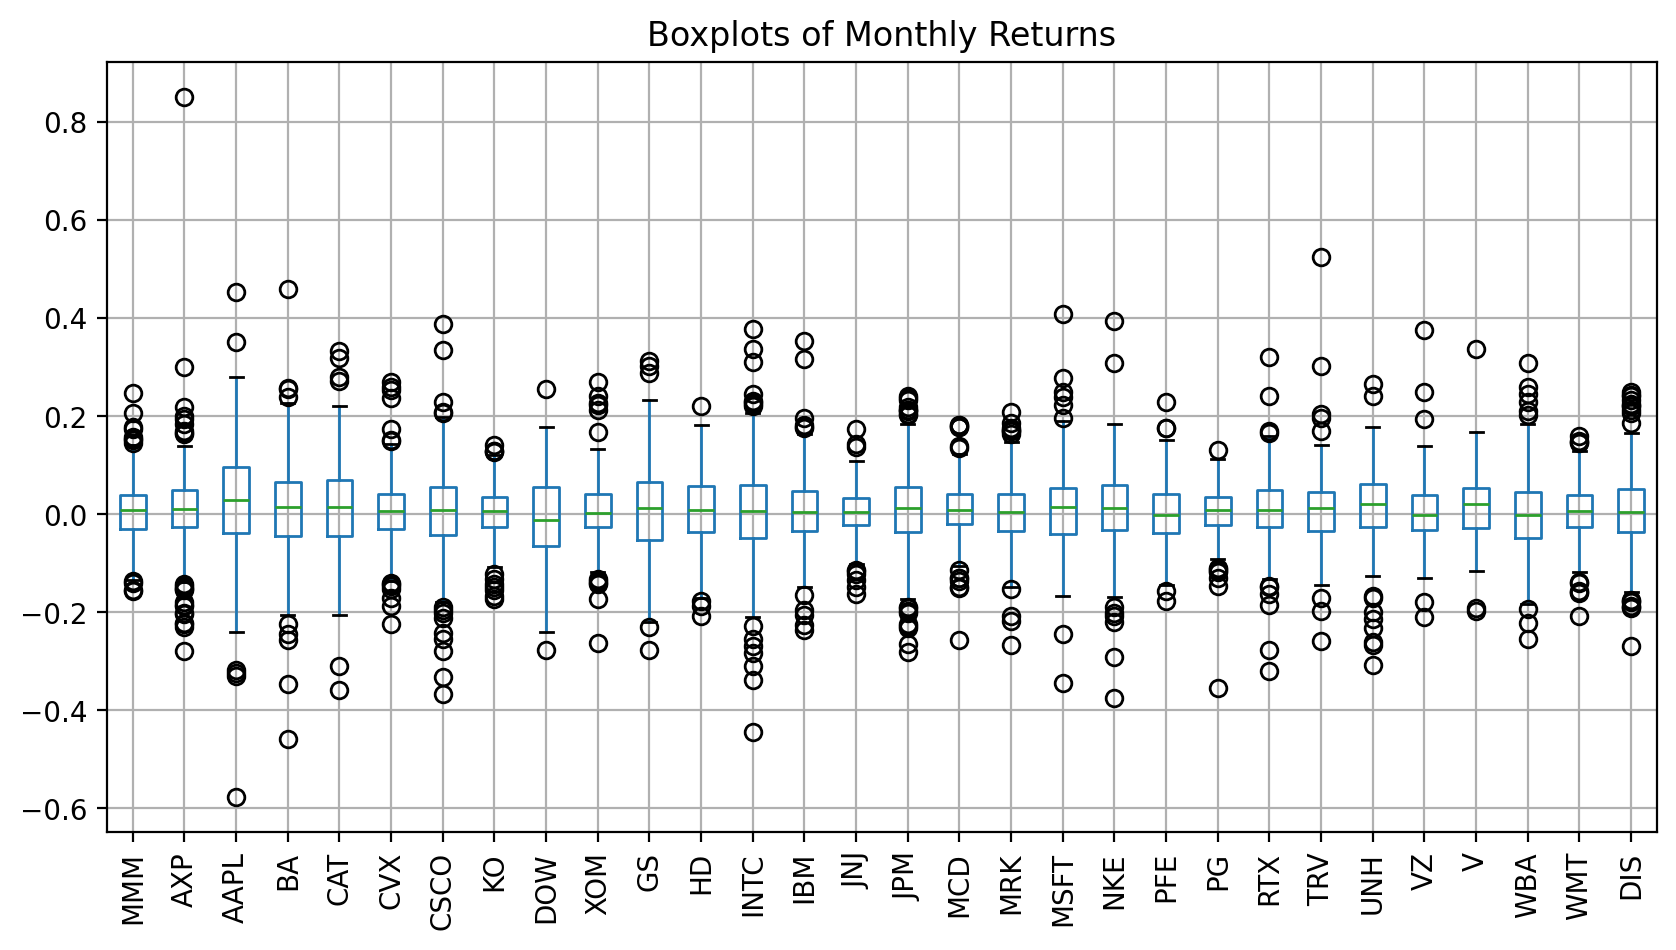

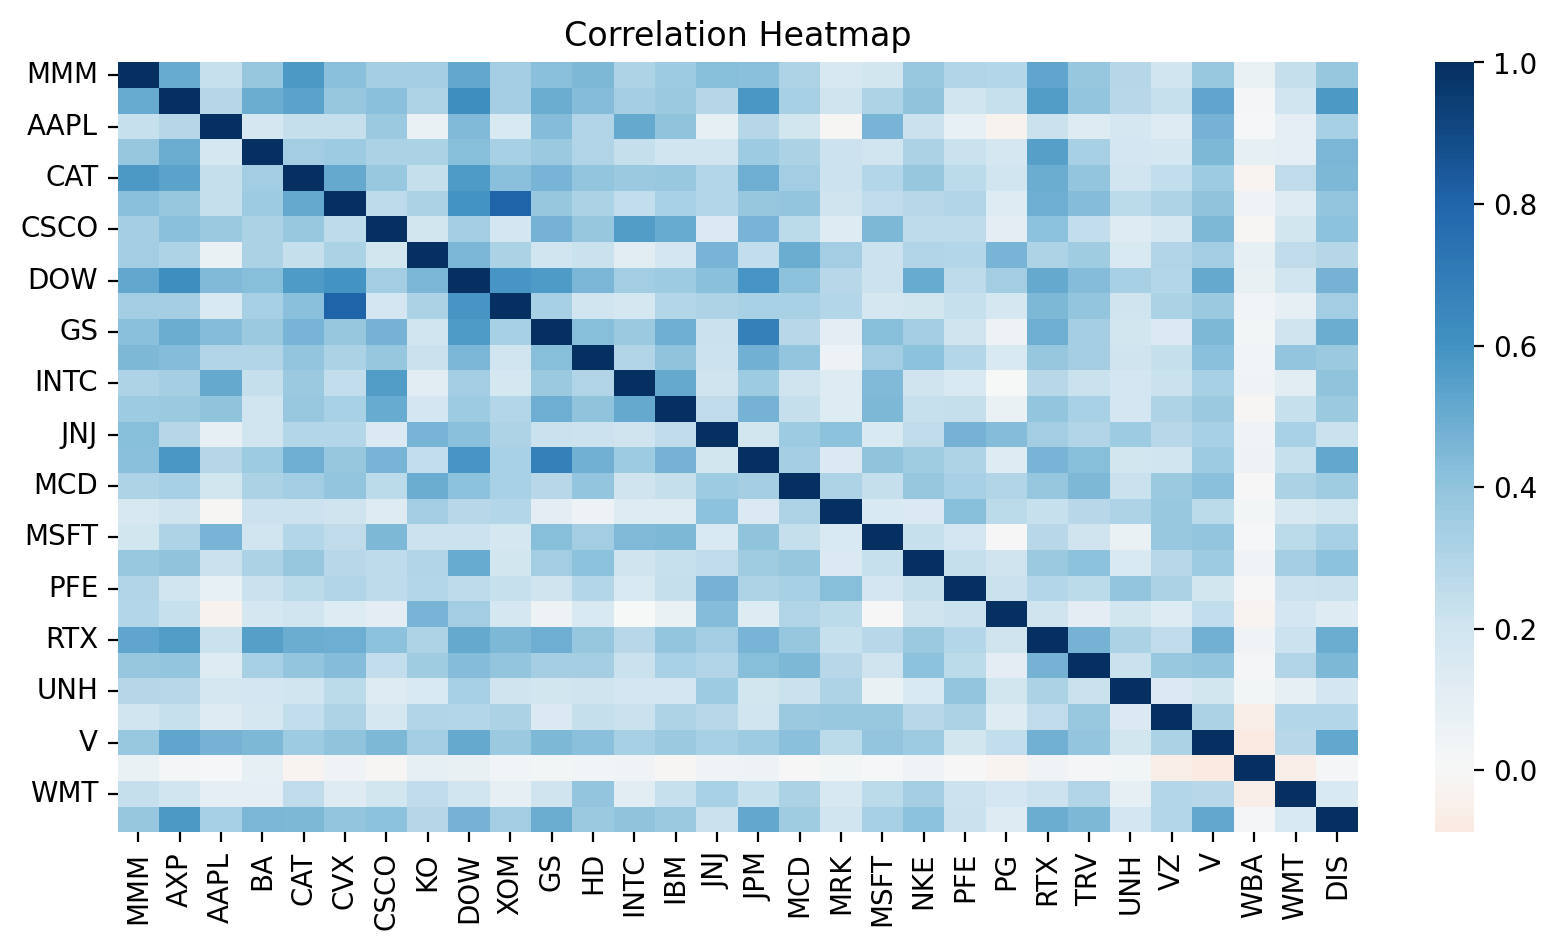

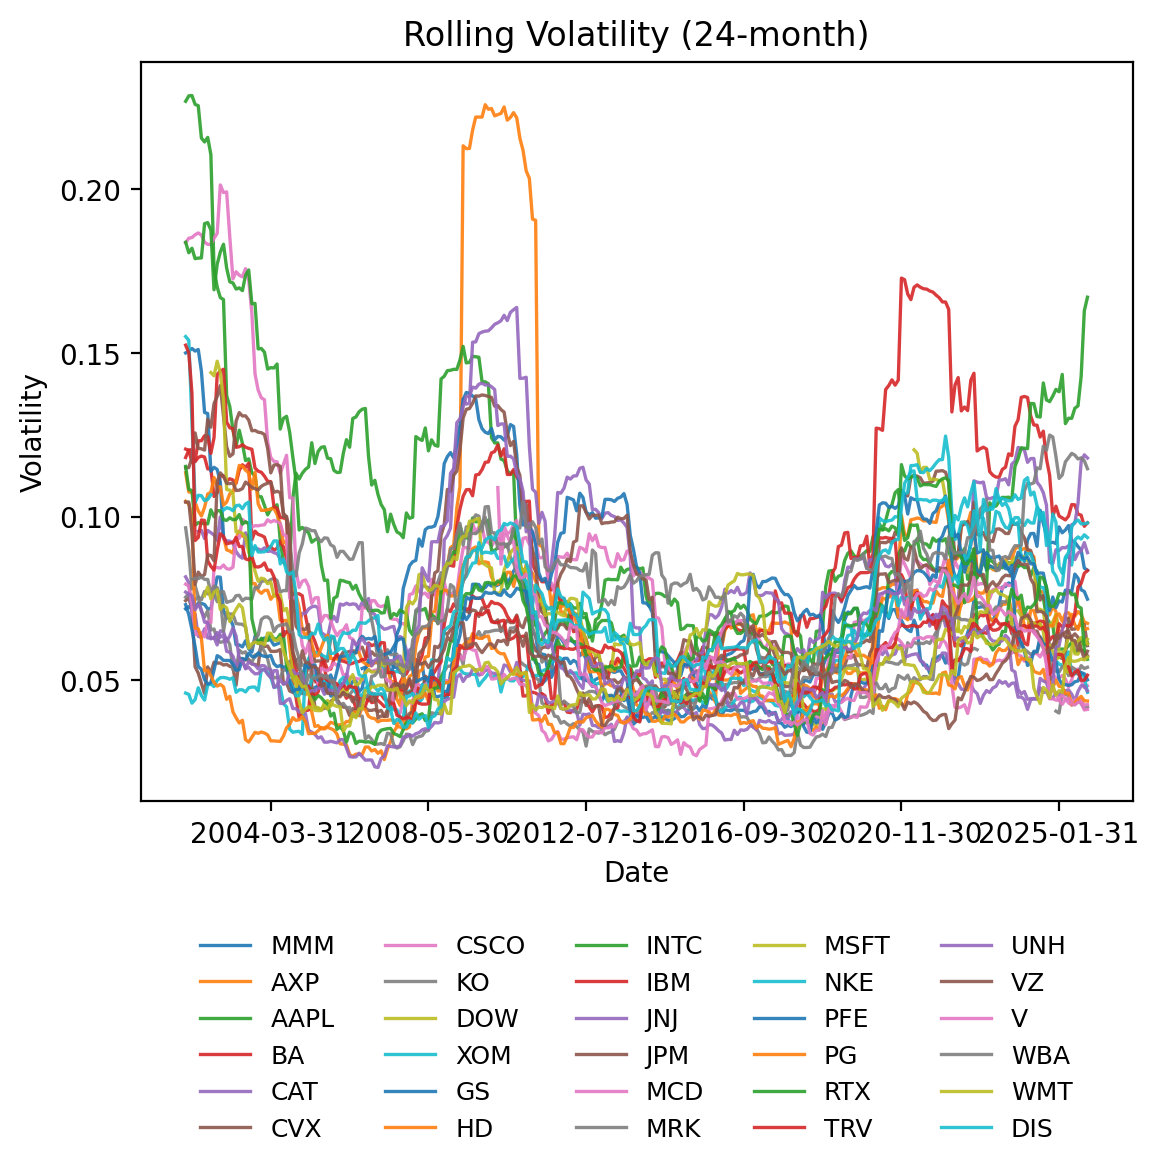

<Figure size 400x800 with 0 Axes>

In [6]:
base_dir = Path("..","plots","data_analysis")

dap = DataAnalysisPlots(monthly_returns, base_dir=base_dir)

print("\n")

dap.plot_boxplots()
dap.plot_corr_heatmap()
dap.plot_rolling_vol(window=24)

dap.print_cov_condition()
dap.print_describe()

dap.display_plots(["boxplots", "correlation_heatmap", "rolling_vol"])

From the rolling volatility plot, we can see that there are periods with high market risk (such as the 2008 crisis or the Covid crisis), so that we can expect that asset risk is highly time-varying, which would affect the optimal portfolios depending on the batch.However, the correlation heatmap reveals medium and heterogeneous correlations across the stoocks, suggesting that diversification is achievable and expected when using tangency portfolios. Moreover, the boxplots show heavy tails, outliers, and non-normal return distributions, implying unstable estimates of means and covariances when applying the different portfolio optimisation techniques.

Therefore, we can claim that the data exhibits typical stock return characteristics such as volatility clustering, imperfect correlations, and non-Gaussian behavior, which highlights the challenges of classical Markowitz estimation and motivates the use of robust techniques such as the ones we will try.

---

### Third Step: Performance Analysis of Original Markowitz Tangency Portfolio

From the returns data, we need to compute the mean vector and the covariance matrix of the data, annualized for comparability:

In [7]:
mu_returns: pd.Series = ann_rets(monthly_returns,FREQ_DATA)
cov_returns: pd.DataFrame = cov_mat(monthly_returns,FREQ_DATA)
n_obs: int = monthly_returns.shape[0]

The Markowitz Optimal Portfolio given the data is the following:

In [8]:
weights, opt_ret, opt_vol = markowitz_tangency_ptf(mu_ret=mu_returns, cov_ret=cov_returns)
orig_markowitz_opt_ptf = (opt_ret,opt_vol**2)
OPT_PTFS["orig_markowitz"] = plot_ptf(mv_pair=orig_markowitz_opt_ptf,color = "green")
ptf_results_print(opt_ret, opt_vol, weights)

Optimal Return: 0.0904 | Optimal Volatility: nan

Weights by Stock:

MMM: 0.8122 | AXP: 0.4463 | AAPL: -0.2826 | BA: 0.3231 | CAT: -0.4854
CVX: 0.6788 | CSCO: -0.4741 | KO: 0.9835 | DOW: -2.8055 | XOM: 2.5362
GS: 0.4751 | HD: 0.3801 | INTC: 0.8203 | IBM: -0.0925 | JNJ: -0.1851
JPM: -0.0400 | MCD: -0.6845 | MRK: -0.1422 | MSFT: -0.7461 | NKE: 0.8631
PFE: 0.3321 | PG: 0.1878 | RTX: 0.0957 | TRV: -1.2160 | UNH: -0.2573
VZ: -0.0150 | V: -1.4592 | WBA: -0.1326 | WMT: 0.1900 | DIS: 0.8937


c:\Users\Iker\Desktop\Warwick\Asset Pricing & Risk\Group Project\asset_pricing_project_group_2\src\utils\optimisers.py:47: RuntimeWarning: invalid value encountered in sqrt
  vol_opt: float = float(np.sqrt(w @ cov_ret @ w))


Now we can get an overview of the mean-variance frontier and visualize where the optimal Markowitz portfolio is:

Sampling portfolios: 100%|██████████| 75000/75000.0 [00:33<00:00, 2253.45it/s]


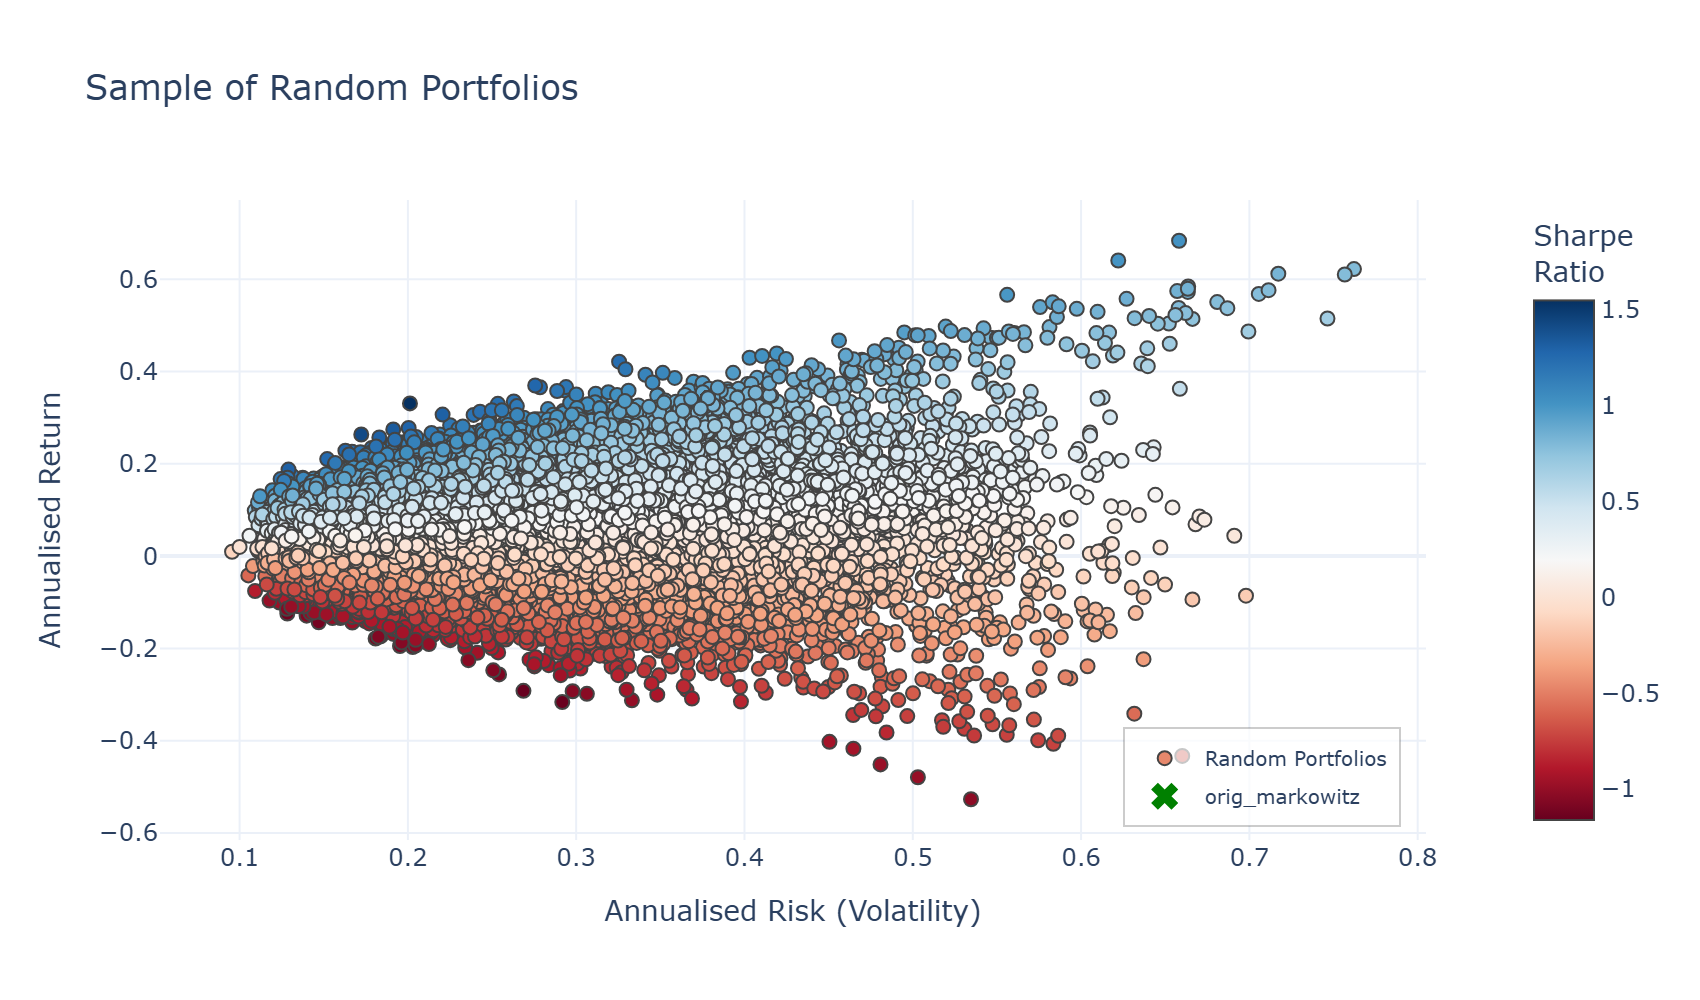

In [9]:
save_path = Path("..","plots","optimal_ptfs","plot_with_original.png")

mv_pairs, _, _ = portfolio_sampler(mu_rets=mu_returns, cov_rets=cov_returns, n_portfolios=N_PTFS, min_assets=1)
mv_plot(mv_pairs,rf=0.02, save_path=save_path, highlight_ptf=OPT_PTFS)

---

### Second Step: Compute Optimal Portfolio by Resampling

Blah blah blah...

In [10]:
weights, opt_ret, opt_vol = resampling_optimiser(mu_ret=mu_returns, cov_ret=cov_returns, n_obs= n_obs, random_state=RANDOM_SEED, n_bootstrap=N_BOOTSTRAP)
resampling_opt_ptf = (opt_ret,opt_vol**2)

c:\Users\Iker\Desktop\Warwick\Asset Pricing & Risk\Group Project\asset_pricing_project_group_2\src\utils\optimisers.py:62: RuntimeWarning:

covariance is not symmetric positive-semidefinite.

c:\Users\Iker\Desktop\Warwick\Asset Pricing & Risk\Group Project\asset_pricing_project_group_2\src\utils\optimisers.py:62: RuntimeWarning:

covariance is not symmetric positive-semidefinite.

c:\Users\Iker\Desktop\Warwick\Asset Pricing & Risk\Group Project\asset_pricing_project_group_2\src\utils\optimisers.py:62: RuntimeWarning:

covariance is not symmetric positive-semidefinite.

c:\Users\Iker\Desktop\Warwick\Asset Pricing & Risk\Group Project\asset_pricing_project_group_2\src\utils\optimisers.py:62: RuntimeWarning:

covariance is not symmetric positive-semidefinite.

c:\Users\Iker\Desktop\Warwick\Asset Pricing & Risk\Group Project\asset_pricing_project_group_2\src\utils\optimisers.py:62: RuntimeWarning:

covariance is not symmetric positive-semidefinite.

c:\Users\Iker\Desktop\Warwick\Asset Pric

In [11]:
OPT_PTFS["resampling_markowitz"] = plot_ptf(mv_pair=resampling_opt_ptf,color="orange")
ptf_results_print(opt_ret, opt_vol, weights)

Optimal Return: 0.3525 | Optimal Volatility: nan

Weights by Stock:

MMM: 0.1118 | AXP: -0.0771 | AAPL: 0.1480 | BA: 0.1177 | CAT: 0.1089
CVX: 0.2086 | CSCO: -0.1760 | KO: 0.1300 | DOW: -0.9886 | XOM: 0.5166
GS: 0.0296 | HD: 0.0473 | INTC: 0.0842 | IBM: -0.0371 | JNJ: 0.1087
JPM: 0.1462 | MCD: -0.0353 | MRK: -0.0528 | MSFT: -0.1275 | NKE: 0.2864
PFE: -0.1227 | PG: 0.1509 | RTX: 0.0663 | TRV: -0.1364 | UNH: 0.2443
VZ: -0.1301 | V: 0.1893 | WBA: 0.0320 | WMT: 0.0300 | DIS: 0.1269


Sampling portfolios: 100%|██████████| 75000/75000.0 [00:33<00:00, 2222.93it/s]


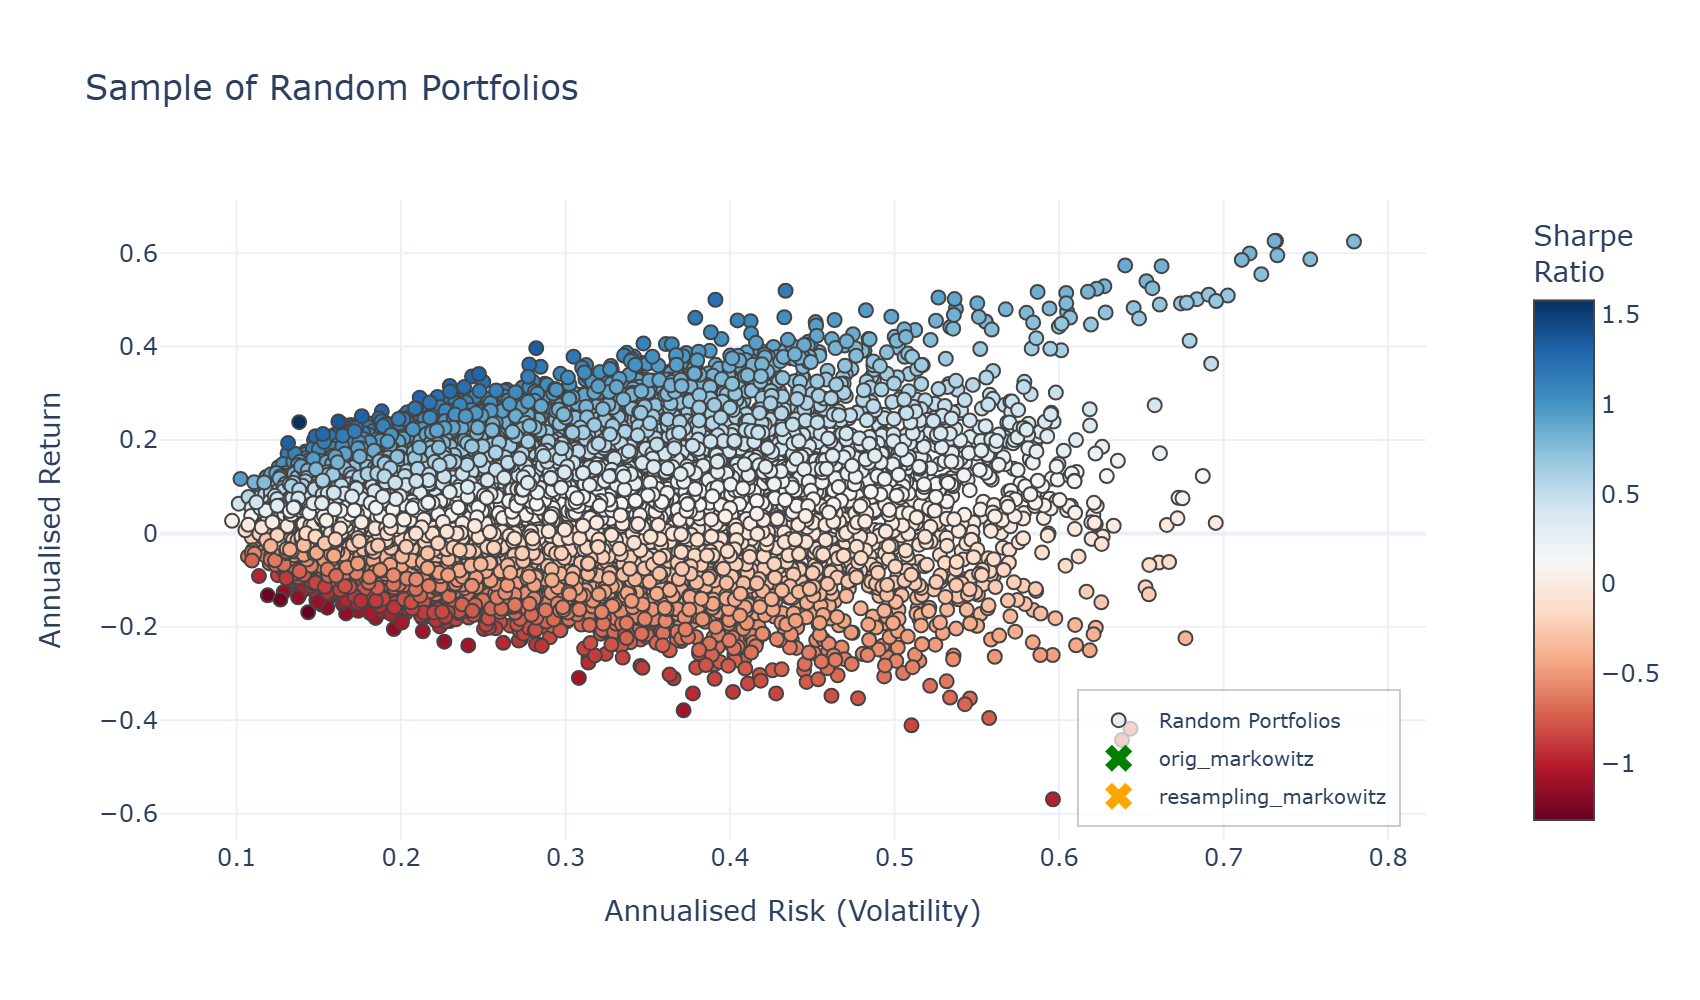

In [12]:
save_path = Path("..","plots","optimal_ptfs","plot_with_resampling.png")

mv_pairs, _, _ = portfolio_sampler(mu_rets = mu_returns,cov_rets = cov_returns, n_portfolios=N_PTFS, min_assets=1)
mv_plot(mv_pairs,rf=0.02, save_path=save_path, highlight_ptf=OPT_PTFS)

---

**Notes for Iker (but use them if you want to motivate yourselves on how to improve your sections):**

- Add graphs as in the papers, that would create a good analysis of the methodologies and results
- Add bar charts for portfolio weights (like in paper)
- Add a graph with optimal resampling B, using MSE (variance/return/sharpe ratio) criteria
- At the end of the implementations, produce a comparitive table between each other in Pandas
- Add graphs and tables for comparing with benchmarks
- Modify/finish Readme.md
- Graph of realized Information Ratios (boxes) of Ledoit(2003a)